In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('fraudTrain.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [4]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [5]:
df['category'].unique()

array(['misc_net', 'grocery_pos', 'entertainment', 'gas_transport',
       'misc_pos', 'grocery_net', 'shopping_net', 'shopping_pos',
       'food_dining', 'personal_care', 'health_fitness', 'travel',
       'kids_pets', 'home'], dtype=object)

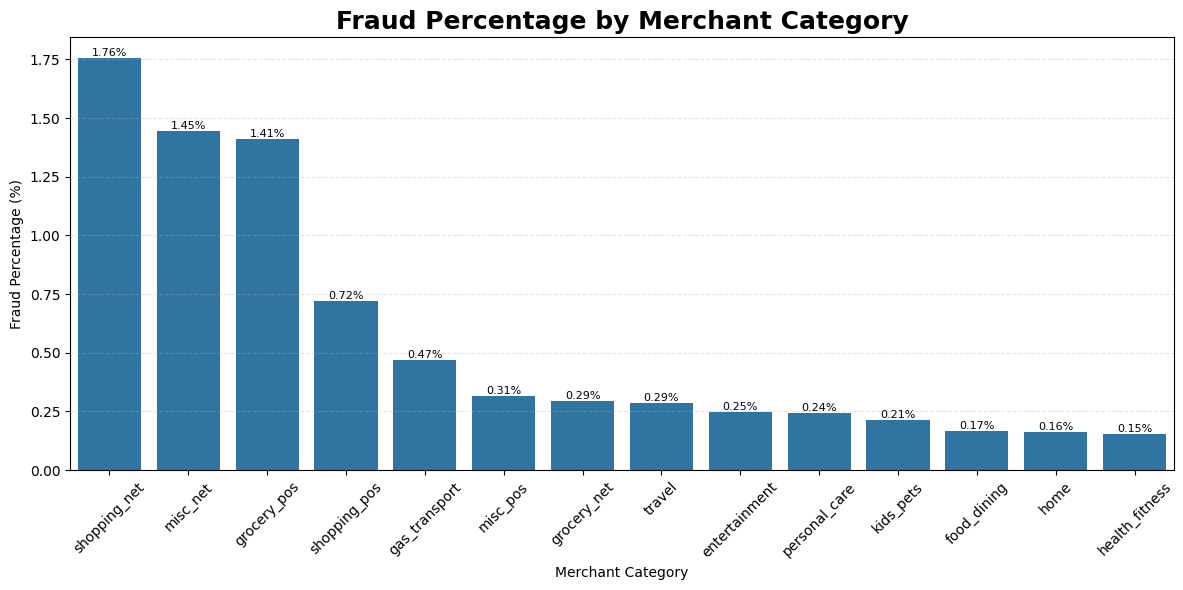

In [6]:
category_fraud = (
    df.groupby('category')['is_fraud']
      .mean()
      .mul(100)
      .reset_index(name='Fraud_Percentage')
      .sort_values(by='Fraud_Percentage', ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=category_fraud,
    x='category',
    y='Fraud_Percentage'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        fontsize=8
    )

plt.title(
    'Fraud Percentage by Merchant Category',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Merchant Category')
plt.ylabel('Fraud Percentage (%)')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

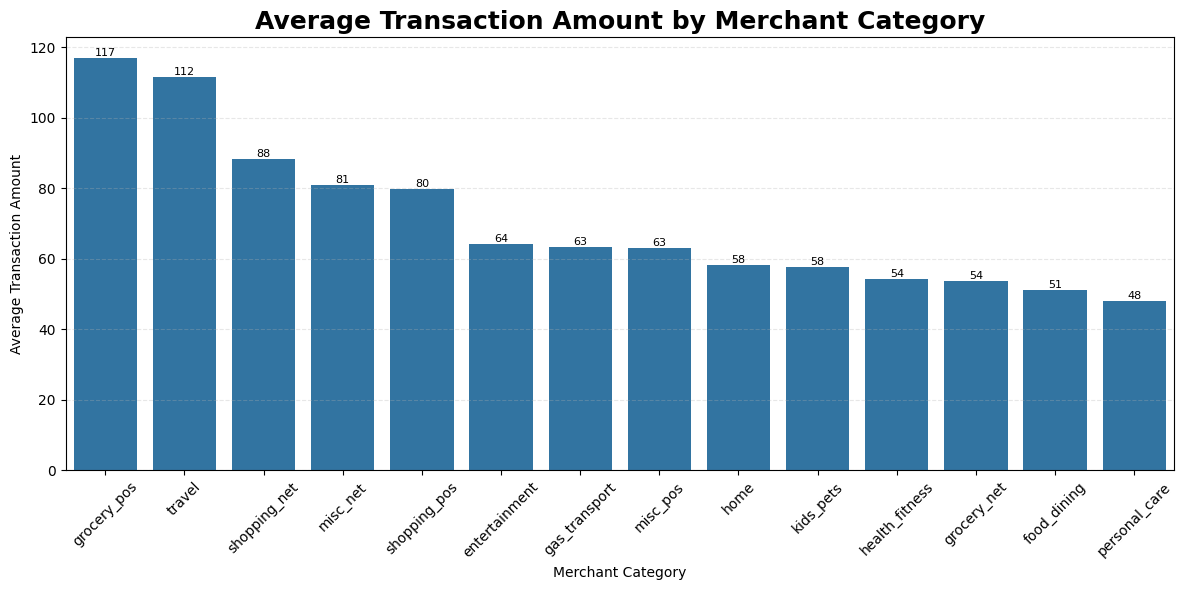

In [7]:
category_amount = (
    df.groupby('category')['amt']
      .mean()
      .reset_index()
      .sort_values(by='amt', ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=category_amount,
    x='category',
    y='amt'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        fontsize=8
    )

plt.title(
    'Average Transaction Amount by Merchant Category',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Merchant Category')
plt.ylabel('Average Transaction Amount')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 1: Merchant Category vs Fraud Rate

The analysis shows that **fraud occurrence varies across merchant categories**, indicating that certain types of businesses are more frequently targeted by fraudulent transactions than others. Identifying these high-risk categories enables fraud analysts to focus monitoring efforts on transactions that are more likely to be suspicious.

Supporting analysis examined the **average transaction amount** for each merchant category. This helps determine whether categories with higher fraud rates also involve larger financial transactions. If a transaction amount is significantly higher than the typical value for its merchant category, it may indicate unusual customer behavior and should be investigated further. Combining merchant category with transaction amount allows banks to identify suspicious transactions more effectively and strengthen fraud prevention strategies.

In [8]:
df['job'].unique()

array(['Psychologist, counselling', 'Special educational needs teacher',
       'Nature conservation officer', 'Patent attorney',
       'Dance movement psychotherapist', 'Transport planner',
       'Arboriculturist', 'Designer, multimedia',
       'Public affairs consultant', 'Pathologist', 'IT trainer',
       'Systems developer', 'Engineer, land', 'Systems analyst',
       'Naval architect', 'Radiographer, diagnostic',
       'Programme researcher, broadcasting/film/video', 'Energy engineer',
       'Event organiser', 'Operational researcher', 'Market researcher',
       'Probation officer', 'Leisure centre manager',
       'Corporate investment banker', 'Therapist, occupational',
       'Call centre manager', 'Police officer',
       'Education officer, museum', 'Physiotherapist', 'Network engineer',
       'Forensic psychologist', 'Geochemist',
       'Armed forces training and education officer',
       'Designer, furniture', 'Optician, dispensing',
       'Psychologist, forensic

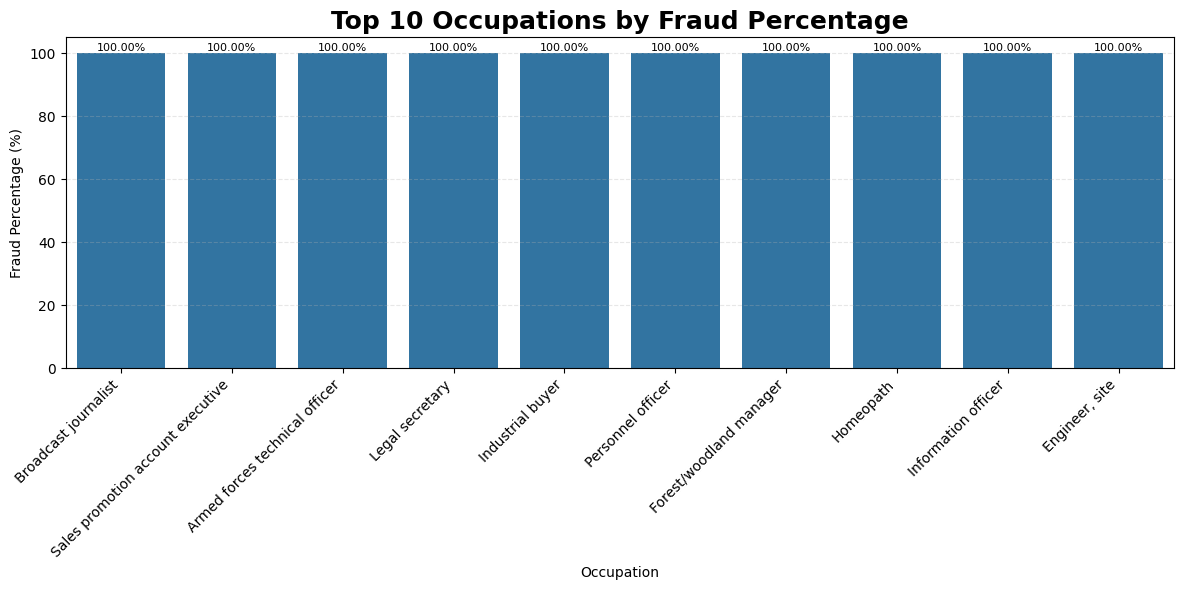

In [10]:
job_fraud = (
    df.groupby('job')['is_fraud']
      .mean()
      .mul(100)
      .reset_index(name='Fraud_Percentage')
      .sort_values(by='Fraud_Percentage', ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=job_fraud,
    x='job',
    y='Fraud_Percentage'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=8)

plt.title(
    'Top 10 Occupations by Fraud Percentage',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Occupation')
plt.ylabel('Fraud Percentage (%)')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

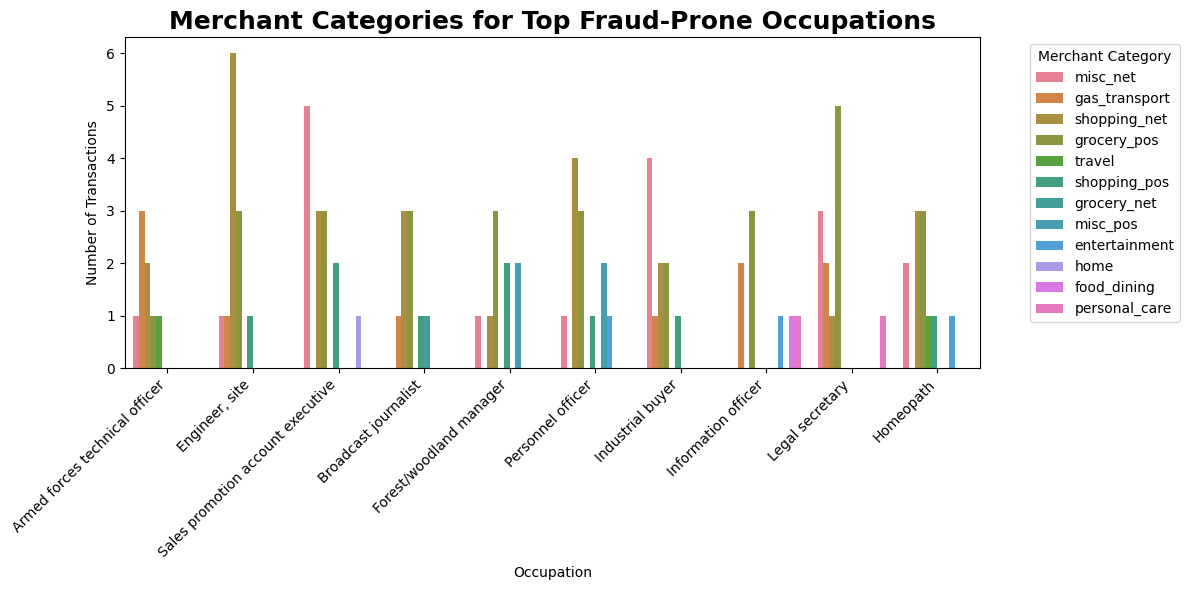

In [12]:
job_category = (
    df.groupby('job')['category']
      .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
      .reset_index(name='Most_Common_Category')
)

top_jobs = (
    df.groupby('job')['is_fraud']
      .mean()
      .mul(100)
      .reset_index(name='Fraud_Percentage')
      .sort_values(by='Fraud_Percentage', ascending=False)
      .head(10)
)

support = top_jobs.merge(job_category, on='job')

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df[df['job'].isin(support['job'])],
    x='job',
    hue='category'
)

plt.title(
    'Merchant Categories for Top Fraud-Prone Occupations',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Occupation')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45, ha='right')

plt.legend(title='Merchant Category', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()

plt.show()

## 💡 Insight 2: Occupation vs Fraud Rate

The analysis identified several occupations that recorded the **highest observed fraud percentages** within this dataset. Although these occupations appear at the top of the ranking, the results should be interpreted with caution because some occupations may have a relatively small number of transactions. Nevertheless, this analysis helps fraud analysts identify customer groups that may require additional monitoring during transaction verification.

Supporting analysis examined the **merchant categories** associated with these occupations. The results show that fraudulent transactions were spread across multiple merchant categories, including **Shopping, Grocery, Gas Transport, Miscellaneous Online Purchases, and Travel**. This indicates that fraudulent activity is **not limited to a single type of merchant**, emphasizing the importance of monitoring customer behavior across different spending categories rather than focusing on one merchant category alone.

By combining **customer occupation** with **merchant category**, fraud analysts can better understand transaction patterns and strengthen fraud detection by identifying unusual purchases that deviate from a customer's normal spending behavior.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [16]:
df['state'].unique()

array(['NC', 'WA', 'ID', 'MT', 'VA', 'PA', 'KS', 'TN', 'IA', 'WV', 'FL',
       'CA', 'NM', 'NJ', 'OK', 'IN', 'MA', 'TX', 'WI', 'MI', 'WY', 'HI',
       'NE', 'OR', 'LA', 'DC', 'KY', 'NY', 'MS', 'UT', 'AL', 'AR', 'MD',
       'GA', 'ME', 'AZ', 'MN', 'OH', 'CO', 'VT', 'MO', 'SC', 'NV', 'IL',
       'NH', 'SD', 'AK', 'ND', 'CT', 'RI', 'DE'], dtype=object)

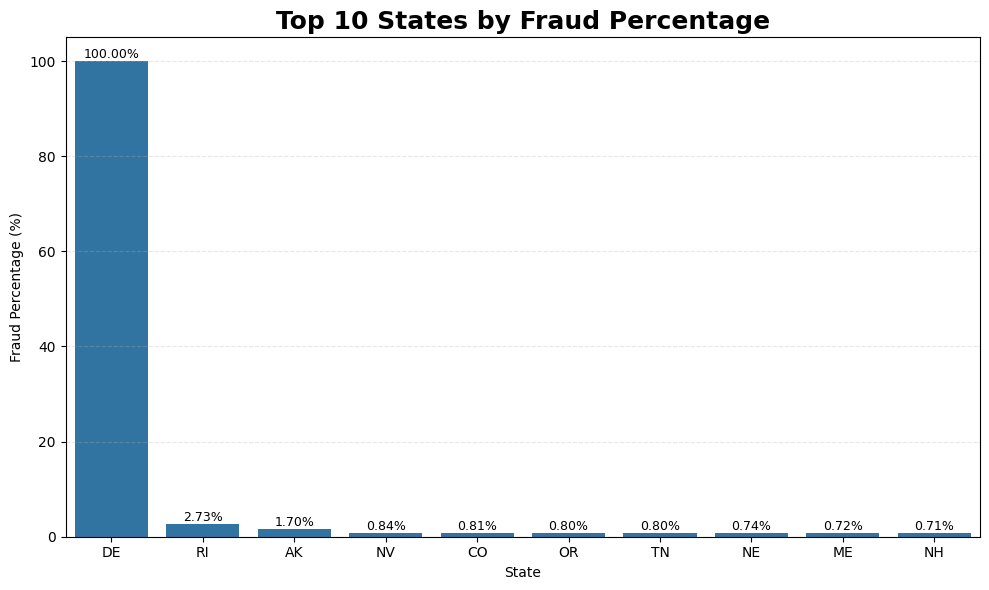

In [17]:
state_fraud = (
    df.groupby('state')['is_fraud']
      .mean()
      .mul(100)
      .reset_index(name='Fraud_Percentage')
      .sort_values(by='Fraud_Percentage', ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=state_fraud,
    x='state',
    y='Fraud_Percentage'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=9)

plt.title(
    'Top 10 States by Fraud Percentage',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('State')
plt.ylabel('Fraud Percentage (%)')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

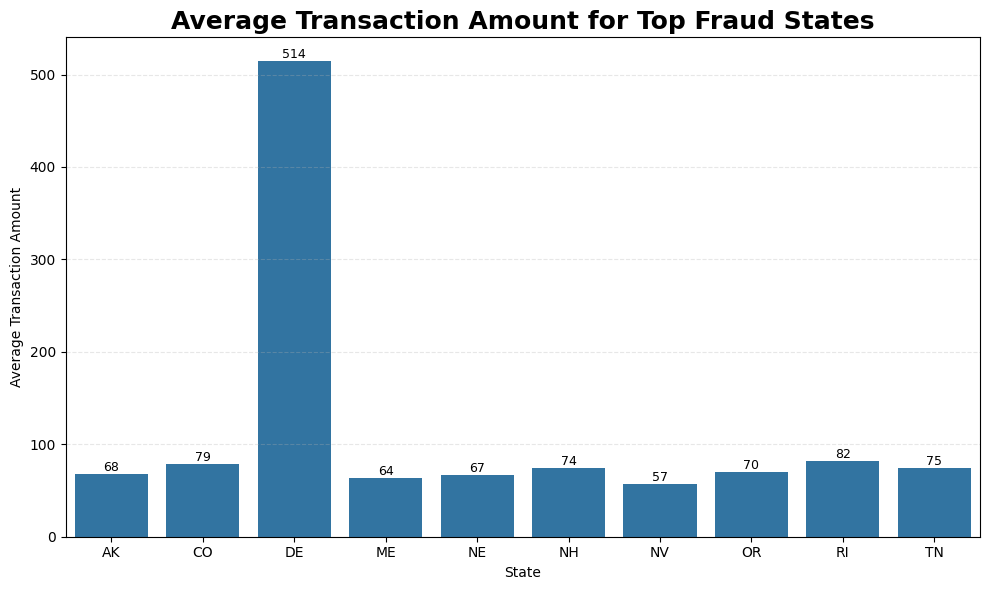

In [19]:
top_states = state_fraud['state']

state_amount = (
    df[df['state'].isin(top_states)]
      .groupby('state')['amt']
      .mean()
      .reset_index(name='Average_Transaction_Amount')
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=state_amount,
    x='state',
    y='Average_Transaction_Amount'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9)

plt.title(
    'Average Transaction Amount for Top Fraud States',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('State')
plt.ylabel('Average Transaction Amount')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 3: State vs Fraud Percentage

The analysis shows that **fraud percentages vary across different states**, with **Delaware (DE)** recording the highest observed fraud percentage in this dataset. However, this result should be interpreted with caution because states with a relatively small number of transactions can produce unusually high fraud percentages. Despite this limitation, the analysis helps fraud analysts identify regions that may require closer monitoring and further investigation.

Supporting analysis examined the **average transaction amount** across the top fraud-prone states. Among these states, **Delaware** also recorded the highest average transaction amount (**approximately $514**), while the remaining states showed considerably lower average transaction values. This suggests that fraudulent activity in certain regions may also involve higher-value transactions, making them more financially risky for banks.

By combining **geographical information** with **transaction amount**, fraud analysts can prioritize high-risk regions, improve transaction monitoring, and implement additional verification measures for unusually large transactions originating from these locations.

In [20]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df['Transaction_Hour'] = df['trans_date_trans_time'].dt.hour

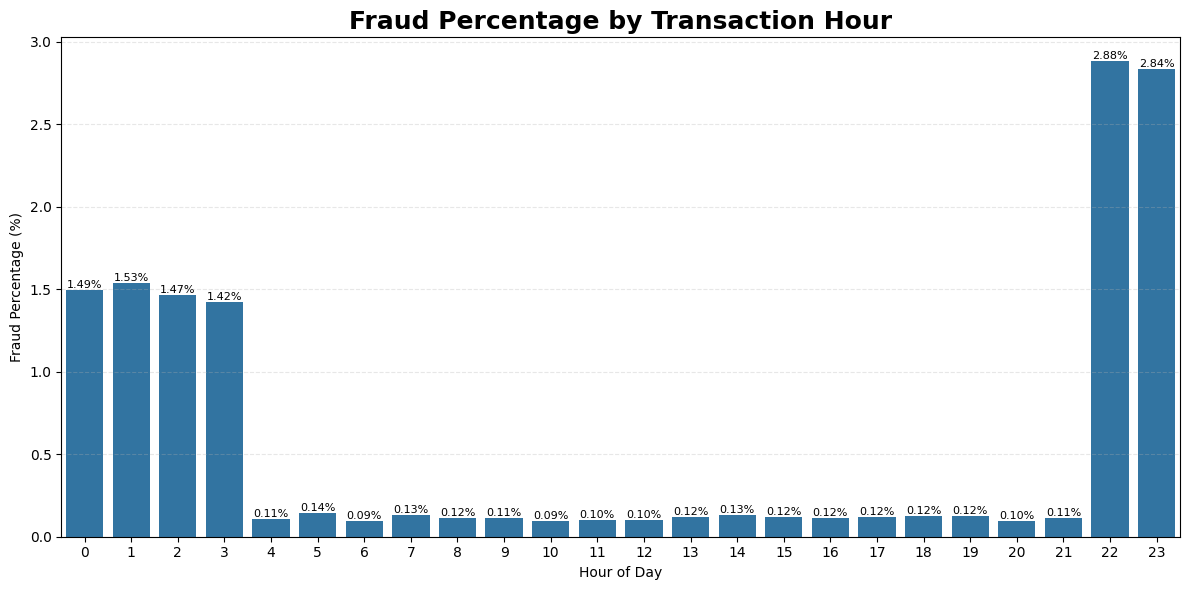

In [21]:
hour_fraud = (
    df.groupby('Transaction_Hour')['is_fraud']
      .mean()
      .mul(100)
      .reset_index(name='Fraud_Percentage')
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=hour_fraud,
    x='Transaction_Hour',
    y='Fraud_Percentage'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=8)

plt.title(
    'Fraud Percentage by Transaction Hour',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Hour of Day')
plt.ylabel('Fraud Percentage (%)')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

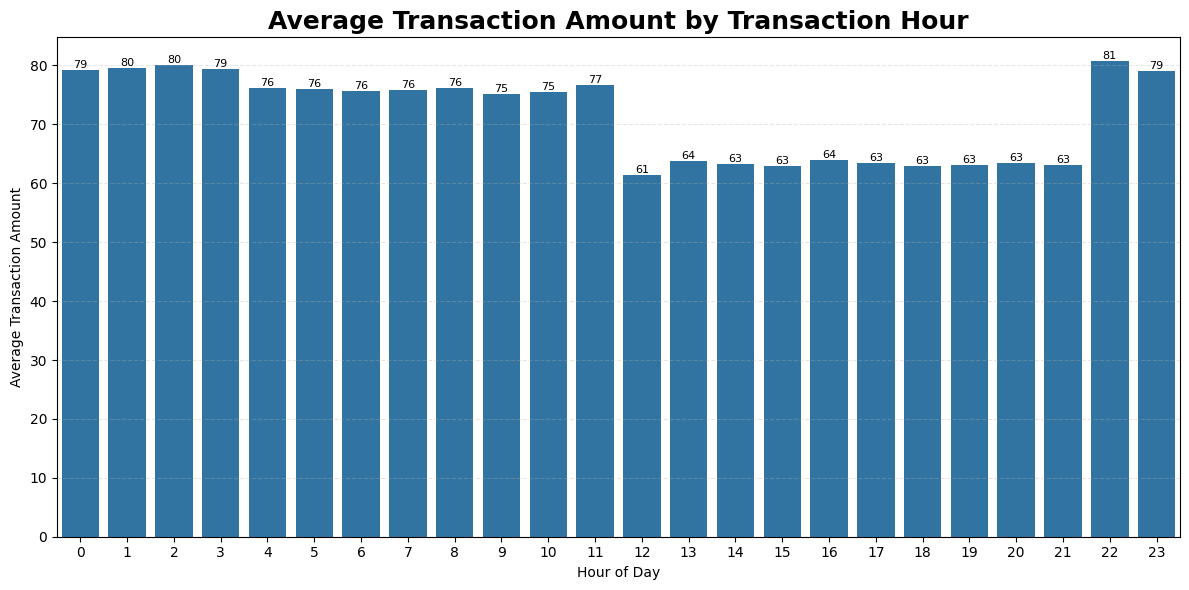

In [22]:
hour_amount = (
    df.groupby('Transaction_Hour')['amt']
      .mean()
      .reset_index(name='Average_Amount')
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=hour_amount,
    x='Transaction_Hour',
    y='Average_Amount'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8)

plt.title(
    'Average Transaction Amount by Transaction Hour',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Hour of Day')
plt.ylabel('Average Transaction Amount')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 4: Transaction Hour vs Fraud Percentage

The analysis reveals that **fraudulent transactions are significantly more frequent during late-night hours**, particularly between **10:00 PM (22:00)** and **11:00 PM (23:00)**, where the fraud percentage reaches approximately **2.88%** and **2.84%**, respectively. Fraud rates are also relatively higher between **12:00 AM and 3:00 AM**, while the remaining hours of the day exhibit very low fraud percentages.

Supporting analysis examined the **average transaction amount by transaction hour**. The results show that **late-night hours (22:00–23:00)** not only experience the highest fraud percentages but also record the **highest average transaction amounts** (approximately **$81** and **$79**). This indicates that fraudsters may target high-value transactions during late-night hours when customers are less likely to notice unauthorized card activity.

By combining **transaction time** with **transaction amount**, financial institutions can implement **time-based fraud detection rules**, apply additional verification for high-value transactions during high-risk hours, and improve the accuracy of real-time fraud detection systems while reducing potential financial losses.

In [24]:
df['merchant'].nunique()

693

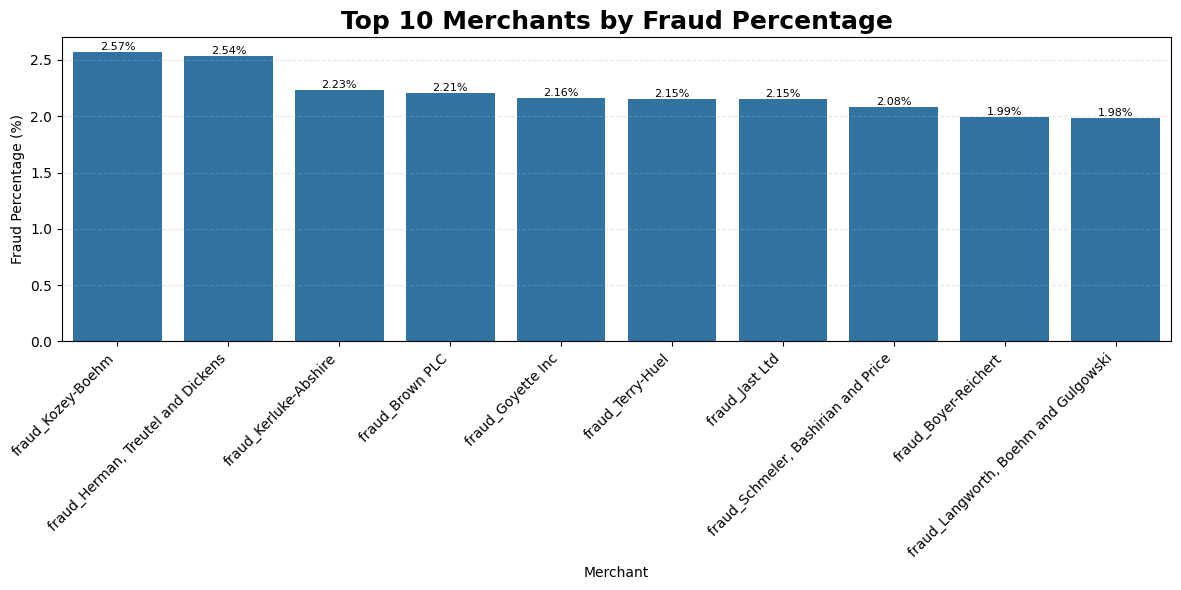

In [25]:
merchant_fraud = (
    df.groupby('merchant')['is_fraud']
      .mean()
      .mul(100)
      .reset_index(name='Fraud_Percentage')
      .sort_values(by='Fraud_Percentage', ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=merchant_fraud,
    x='merchant',
    y='Fraud_Percentage'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=8)

plt.title(
    'Top 10 Merchants by Fraud Percentage',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Merchant')
plt.ylabel('Fraud Percentage (%)')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

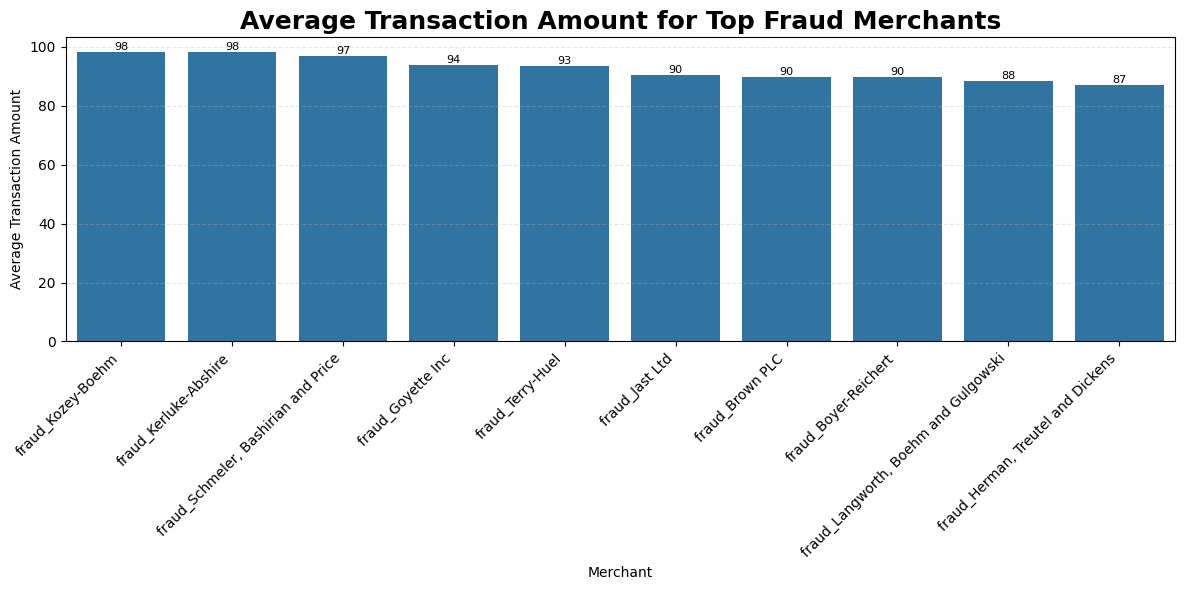

In [27]:
top_merchants = merchant_fraud['merchant']

merchant_amount = (
    df[df['merchant'].isin(top_merchants)]
      .groupby('merchant')['amt']
      .mean()
      .reset_index(name='Average_Transaction_Amount')
      .sort_values(by='Average_Transaction_Amount', ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=merchant_amount,
    x='merchant',
    y='Average_Transaction_Amount'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8)

plt.title(
    'Average Transaction Amount for Top Fraud Merchants',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Merchant')
plt.ylabel('Average Transaction Amount')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 5: Merchant vs Fraud Percentage

The analysis identified the **top merchants with the highest observed fraud percentages** within the dataset. These merchants consistently recorded fraud rates ranging from approximately **2.0% to 2.6%**, indicating that fraudulent transactions are more concentrated among certain merchants than others. Identifying these merchants enables financial institutions to prioritize monitoring efforts and strengthen fraud prevention strategies.

Supporting analysis examined the **average transaction amount** for these high-risk merchants. The results show that these merchants also processed **relatively higher-value transactions**, with average transaction amounts ranging from approximately **$87 to $98**. This suggests that fraudsters may target merchants where higher-value transactions are more common, increasing the potential financial impact of fraudulent activity.

By combining **merchant-level fraud analysis** with **transaction amount**, banks can develop merchant-specific risk profiles, apply enhanced verification for high-risk merchants, and improve real-time fraud detection by identifying unusual transactions before financial losses occur.

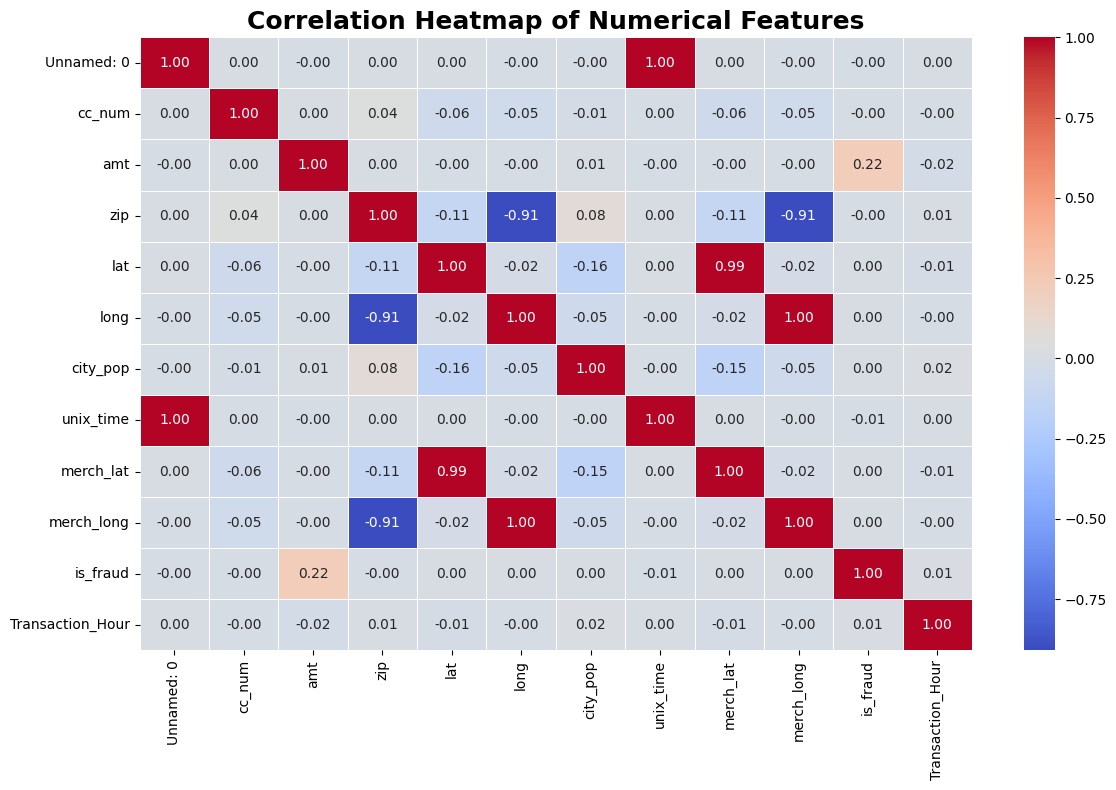

In [28]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

## 💡 Multivariate Analysis: Correlation Heatmap

A correlation heatmap was used to examine the relationships among the numerical variables in the dataset. This analysis helps identify which features move together and provides a broader understanding of the factors associated with fraudulent transactions.

The heatmap indicates that **transaction amount (amt)**, **transaction time (unix_time)**, **customer location (latitude and longitude)**, **merchant location**, and **city population** exhibit varying degrees of correlation with one another. Most numerical variables show **weak to moderate correlations**, suggesting that fraudulent behavior cannot be explained by a single feature alone.

The analysis reinforces that **credit card fraud is a multi-factor problem**, where transaction amount, transaction timing, merchant information, geographical location, and customer behavior collectively contribute to identifying suspicious transactions. These findings support the need for combining multiple variables when building fraud detection models rather than relying on any individual feature.

# ✅ Conclusion

This Exploratory Data Analysis (EDA) identified several factors associated with fraudulent credit card transactions by analyzing merchant behavior, customer occupations, geographical regions, transaction timing, and spending patterns.

The analysis revealed that fraud is not randomly distributed across transactions. Certain **merchant categories**, **merchants**, and **states** recorded higher fraud percentages, indicating that fraudulent activity is more concentrated in specific areas of the transaction ecosystem. In addition, **late-night transactions (particularly between 10 PM and 11 PM)** exhibited the highest fraud percentages and were also associated with higher average transaction amounts, making transaction time one of the strongest indicators of suspicious activity.

The study also demonstrated that combining multiple transaction attributes, such as merchant information, transaction amount, location, and transaction time, provides a stronger understanding of fraud patterns than relying on any single feature. The correlation heatmap further highlighted relationships among numerical variables, supporting the importance of behavioral and transactional features in fraud analysis.

Overall, this analysis provides valuable business insights that can help financial institutions strengthen fraud monitoring, improve risk assessment, and develop more effective real-time fraud detection strategies.

# 📌 Business Recommendations

- Monitor high-risk merchant categories more closely by applying stricter fraud detection rules.
- Implement merchant-specific risk scoring for merchants with consistently higher fraud percentages.
- Increase monitoring and verification for transactions originating from high-risk states.
- Apply additional authentication (OTP, biometric verification, or transaction holds) for high-value transactions occurring during late-night hours.
- Continuously monitor transaction behavior by combining multiple features such as merchant, transaction amount, location, and transaction time instead of relying on a single attribute.
- Use the identified fraud patterns as input features for building machine learning models capable of detecting fraudulent transactions in real time.